# MNIST Neural Network

In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing Dataset

In [296]:
data = pd.read_csv("train.csv")

In [297]:
data.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [298]:
data.tail(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
41990,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41991,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41992,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41993,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41994,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41999,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [299]:
data.info

<bound method DataFrame.info of        label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0          1       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          1       0       0       0       0       0       0       0       0   
3          4       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995      0       0       0       0       0       0       0       0       0   
41996      1       0       0       0       0       0       0       0       0   
41997      7       0       0       0       0       0       0       0       0   
41998      6       0       0       0       0       0       0       0       0   
41999      9       0       0       0       0       0       0       0       0   

       

In [300]:
data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Formatting Data

In [301]:
data = np.array(data)

#Getting dimensions of the data
#42000 rows, 785 cols -> 1 label + 784 pixels
m,n = data.shape

#For training shuffling the data
np.random.shuffle(data)

In [302]:
print(m,n)

42000 785


### Important Terminologies
We use separate datasets to learn, tune, and evaluate a model.

**Train set:** 
- The model learns digit patterns by updating weights using backpropagation
   
**Dev (validation) set:**
- Used to tune hyperparameters and training decisions
  
**Test set:**
- Used once at the end for final performance measurement.
- Here the labels are hidden, so Kaggle evaluates the predictions for us

This separation prevents overfitting and ensures reliable generalization.

So just a dev/train split is needed

In [303]:
#Creating dev/train split to check for overfitting
#Following 80% train 20% dev split
split = int(0.2 * m)
data_dev = data[0:split]

#Transposing the data
data_dev = data_dev.T
#Label values
Y_dev = data_dev[0]
#Remove the label column only pixels
X_dev = data_dev[1:n]

In [304]:
data_train = data[split:m]

#Transposing the data
data_train = data_train.T
#Label values
Y_train = data_train[0]
#Remove the label column only pixels
X_train = data_train[1:n]

### X Y split explained
- After transposing the numpy array,
- label became the first row,
- the rest 1:785 columns are pixels

- Thus, data_(dev/train)[0] gives lables
- And, data_(dev/train)[1:785] gives pixels
- Visualizing for better understanding

In [305]:
data_dev #First row is labels

array([[7, 2, 6, ..., 6, 4, 9],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [306]:
Y_dev

array([7, 2, 6, ..., 6, 4, 9])

In [307]:
X_dev = X_dev/255
X_dev

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [308]:
data_train #First row is labels

array([[0, 0, 1, ..., 0, 8, 3],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [309]:
Y_train

array([0, 0, 1, ..., 0, 8, 3])

In [310]:
X_train = X_train/255
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# Neural Net

## Maths behind initializing parameters
- We need to generate random values for the weights and biases for initialization
- So what range to keep to ensure
- No vanishing or exploding gradients/activations
- Control parameters needed:
    - mean = 0
    - controlled variance

### Why mean should be 0?
Let us look at one neuron
  $$z = w_1x_1 + w_2x_2 + \dots + w_nx_n$$
Taking expectation or average behaviour
  $$E[z] = E[w_1]E[x_1] + \dots + E[w_n]E[x_n]$$
If weights are symmetric around 0, that is mean = 0
  $$E[w_i] = 0 \Rightarrow E[z] = 0$$
Thus half neurons positive, half neurons negative

Thus we have a variety in gradients

If mean ≠ 0
  $$E[w_i] \neq 0 \Rightarrow z \text{ shifts in one direction}$$

### Why controlled variance is needed?
Controlled variance implies that we can't have a big range
- Variance of weighted sum:
    $$\text{Var}(z) = n \cdot \text{Var}(w) \cdot \text{Var}(x)$$
- In each layer we will be multipliying variance
  $$\text{Var}(z_L) = k^L \text{Var}(z_0)$$
- So after a few layers we will have $$z \to \infty$$

This is the **vanishing/exploding gradient problem.**

### Why (-0.5, 0.5) Range Chosen?
- Mean = 0
- Small Range
- But also it satisfies the condition:
  $$\text{Var}(w) = \frac{2}{n_{in}} \text{ (ReLU)}$$
- Because we want
  $$\text{Var}(z_{\text{layer}}) \approx \text{Var}(z_{\text{previous}})$$
- Proof :
  - In each layer we multiply gradients, assuming k layers
    $$\text{Var}(z_L) = k^L \text{Var}(z_0)$$
  - We want signal strength to be preserved, that is not vanish or explode, So
    $$\text{Var}(z_{\text{layer}}) \approx \text{Var}(z_{\text{previous}})$$
  - Following constraints need to be met
    | Condition | Outcome |
| :--- | :--- |
| **$k > 1$** | **Explosion:** Variance grows exponentially, leading to numerical instability. |
| **$k < 1$** | **Vanishing:** Variance shrinks to zero; the network stops learning. |
| **$k = 1$** | **Stable Learning:** Signal variance is preserved throughout the network. |
  - Thus, solving for weight variance, we get
    $$\text{Var}(w) = \frac{2}{n_{in}} \text{ (ReLU)}$$
  - This gives **He Initialization**
    $$W \sim \mathcal{N}\left(0, \frac{2}{n_{in}}\right)$$
    
### Range Analysis

| Range | What happens |
| :-- | :-- |
| **$(0, 1)$** | **Neurons identical:** Symmetry isn't broken, neurons learn the same features. |
| **$(-1, 0)$** | **Neurons dead:** For ReLU, weights start in the "off" zone, causing dead neurons, also known as **dying ReLU problem** |
| **$(-1, 1)$** | **Exploding signals:** The range is too wide for deep architectures without normalization. |
| **$(-0.5, 0.5)$** | **Works shallow only:** Initial signal is okay, but degrades in deeper layers. |
| **He Init** | **Stable deep learning:** Specifically tuned to keep $k \approx 1$ for ReLU. |

## How to initialize parameters
- For input layer , or Layer 0,
- We have 784 neurons, 1st layer has 32 neurons
- Now, each neuron in 0th layer is connected to each neuron in 1st layer

### Weights
- so for that 1 singular neuron we need 32 weights for each of it's connections in the 1st layer
- Similary we have to do it for all the neurons in the 0th layer, which are 784 in total
- So we can generate a random values array of size :
- 32 rows x 784 columns

### Bias
- For each singular neuron in 1st layer, we need to add a singular bias value
- Thus in 1st layer we have 32 neurons so, we need 32 bias values
- So we can generate a random values array of size :
- 32 rows x 1 column

### Layers
- Now for each layer we can repeat this process

### Generalizing
- **Wn = np.random.rand(len(layer n+1), len(layer n))**
- **Bn = np.random.rand(len(layer n+1), 1)**

### Architecture
layers(784,32,16,10)
- 784 neurons in input layer
- 10 neurons in output layer(for each digit 0-9)
- 2 hidden layers
- 1st hidden layer is 32 neurons
- 2nd hidden layer is 16 neurons

In [311]:
#Initializing the starting weights and biases
def init_params():
    #np.random.randn gives value between [0,1] so,
    #[0,1] - 0.5 = [-0.5,0.5]
    W1 = np.random.rand(32,784) - 0.5
    b1 = np.random.rand(32,1) - 0.5
    W2 = np.random.rand(16,32) - 0.5
    b2 = np.random.rand(16,1) - 0.5
    W3 = np.random.rand(10,16) - 0.5
    b3 = np.random.rand(10,1) - 0.5
    return W1,b1,W2,b2,W3,b3 

In [312]:
print(init_params())

(array([[ 0.47531319, -0.35187279, -0.01650288, ..., -0.41782352,
         0.08483511,  0.11930974],
       [ 0.21742004, -0.0672926 ,  0.42384293, ..., -0.28895266,
        -0.36708457, -0.45575529],
       [-0.41607835,  0.05930101,  0.36211877, ...,  0.15789458,
         0.24869168,  0.114435  ],
       ...,
       [ 0.33015091, -0.11896434,  0.05825297, ..., -0.37591113,
        -0.46527998, -0.04940323],
       [-0.29553008,  0.38630454, -0.08513688, ..., -0.47561968,
        -0.36785885, -0.26325204],
       [ 0.10976195,  0.24744652,  0.27160981, ..., -0.18342926,
        -0.46092449,  0.16888674]]), array([[-0.42757306],
       [-0.30619211],
       [-0.09675931],
       [-0.26429287],
       [-0.34541707],
       [-0.18490712],
       [ 0.05621274],
       [ 0.0275416 ],
       [-0.25117712],
       [-0.01786164],
       [ 0.1111996 ],
       [-0.32589672],
       [ 0.48427597],
       [ 0.32358235],
       [ 0.33405652],
       [-0.24332876],
       [ 0.38626224],
       [-0.

### Utility Functions

In [313]:
#Non Linear Function -> Rectified Linear Unit
def ReLU(Z):
    #Iterator style for each element
    return np.maximum(0,Z)

def derivative_ReLU(Z):
    return Z>0

#To get probability distribution in output layer
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

#To one hot encode the labels
def one_hot(Y):
    #Creating matrix for labels Y and init with 0
    matrix_Y = np.zeros((Y.size,Y.max()+1))
    #Setting that particular cell to 1
    matrix_Y[np.arange(Y.size),Y] = 1
    #Taking transpose
    matrix_Y = matrix_Y.T
    return matrix_Y

### Terminologies Used
- ##### Z : pre-activation (raw neuron score before activation)

- ##### **𝐴** :  activation (output after nonlinearity)

- ##### **𝑊** : weights (what we are learning)

- ##### **𝑏** : bias (baseline tendency of neuron)

- ##### **𝑑𝑍** : error signal (how much this neuron caused loss), Also called: delta, upstream gradient, local gradient

- ##### **𝑑𝑊** : how weights should change

- ##### **𝑑𝐴** : error passed to previous layer

- ##### g : activation function

## Mapping Scalars to Matrix
- Built in continuation to micrograd, where we used scalars to build things
- Now using matrices to bridge the gap in understanding:
  $$\text{scalar} \rightarrow \text{scalar} \rightarrow \text{scalar} \rightarrow \text{backward}$$
  $$\text{matrices} \rightarrow \text{matrices} \rightarrow \text{matrices} \rightarrow \text{backward}$$

## Math

### 1. For One Neuron
- For one output neuron computing a single training example:
  $$z = w_1a_1 + w_2a_2 + \dots + w_na_n$$
  
  
- Loss depends on $z$: 
  $$L(z)$$
  
  
- We need the gradient with respect to a single weight:
  $$\frac{\partial L}{\partial w_j}$$
  
  
- By chain rule:
  $$\frac{\partial L}{\partial w_j} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial w_j}$$
  
  
- Since $z = \sum w_i a_i$, its derivative with respect to $w_j$ isolates the input:
  $$\frac{\partial z}{\partial w_j} = a_j$$
  
  
- Substituting back into the chain rule:
  $$\frac{\partial L}{\partial w_j} = \delta \cdot a_j \quad \text{where} \quad \delta = \frac{\partial L}{\partial z}$$
- **Global vs Local gradient:**
  - $\delta$ is the global gradient coming backward from the loss function
  - $a_j$ is the local gradient calculated for the current connection
  
  
- **Colloquial understanding:** 
$$\text{gradient wrt weight} = \text{error} \times \text{input}$$


### 2. For Many Neurons
- Assume 10 output neurons (digits 0-9)

- For each individual neuron $k$:
  $$\delta_k = \frac{\partial L}{\partial z_k}$$
  
  
- For each weight $w_{k,j}$ connecting input $j \rightarrow$ neuron $k$:
  $$\frac{\partial L}{\partial w_{k,j}} = \delta_k \cdot a_j$$
  
  
- Stacking all 10 neurons uses an outer product to get the full gradient matrix:
  $$\begin{bmatrix} \delta_1 \\ \delta_2 \\ \vdots \\ \delta_{10} \end{bmatrix} \cdot \begin{bmatrix} a_1 & a_2 & \dots & a_n \end{bmatrix} = \text{gradient matrix}$$
  
  
- Vectorized notation for a single execution pass:
  $$dW = \delta \cdot a^T$$
  
  
- Moving from a single example to a full batch of $m$ images:
  $$dW^{[2]} = dZ^{[2]} A^{[1]T}$$



### 3. Including Batch Dimension ($m$ examples)
- Columns represent independent training examples:
  $$A^{[1]} = \begin{bmatrix} | & | & | \\ a^{(1)} & a^{(2)} & a^{(3)} \\ | & | & | \end{bmatrix}, \quad dZ^{[2]} = \begin{bmatrix} | & | & | \\ \delta^{(1)} & \delta^{(2)} & \delta^{(3)} \\ | & | & | \end{bmatrix}$$
  
  
- We average the gradient across the entire dataset size $m$:
  $$dW = \frac{1}{m} \sum \left(\delta^{(i)} a^{(i)T}\right)$$
  
  
- Matrix multiplication computes this sum and handles the batch averaging simultaneously:
  $$dW = \frac{1}{m} dZ^{[2]} A^{[1]T}$$

### Main Functions

In [314]:
# Writing the loop functions - forward pass, backward pass, update weights
#All the matrix sizes for the parameters except input X1 are defined in init_params fxn

def forward_pass(X,W1,b1,W2,b2,W3,b3):

    #So whatever we get as input(784 pixel values - calling that X)
    # Our X is 784 x No.of training examples - So per training example/image -> 784 x 1
    # Our W1 is 32 x 784
    # So W1.X is (32x784) X (784 x Training_Size) = 32 x Training Size
    # Now b1 is 32 x1 
    # So 32 x Training Size + 32 x 1 -> per training example we can add easily
    Z1 = W1.dot(X) + b1
    
    #Adding Activation Function after 1st Layer Output
    A1 = ReLU(Z1)
    
    #Now A1 is 32 x Training_Size
    #W2 is 16 x 32
    # W2 A1 is 16 x Training_Size
    #b2 is 16 x 1 -> So per training example we can add easiliy
    Z2 = W2.dot(A1) + b2
    
    #Adding Activation Function after 2nd Layer Output 
    A2 = ReLU(Z2)
    
    
    #Now A2 is 16 x Training_Size
    #W3 is 10x16 
    # W3 A2 is 10 x Training_Size
    # b3 is 10 x 1 -> So per training example we can add easily
    Z3 = W3.dot(A2) + b3
    
    #Now we want probability distribution as this is the output layer
    #Thus activation function is softmax
    A3 = softmax(Z3)
    
    return Z1,A1,Z2,A2,Z3,A3

def backward_pass(X,Y,Z1,A1,Z2,A2,Z3,A3,W1,W2,W3):

    #So whatever we get as output(10 values(probability distribution) - calling that Y)
    m = Y.size
    one_hot_Y = one_hot(Y)
    
    #Actual Loss/Error Calculation - Taking Cross Entropy Loss with Softmax
    #So derivative just simplied to A-Y
    dZ3 = A3 - one_hot_Y
    
    #For the weights change => 1/batch-size * loss * activation
    #So 1/m * (10x1) x (1x16) = 10x16 this is our W3 size
    #We just need to get local grad, which for ∑xi*wi , is just xi which of course is just the derivative
    dW3 = 1/m * dZ3.dot(A2.T)
    
    #We are considering all the training examples at once for training
    # This becomes more clearer in this , that is where 1/m comes
    #So dZ3 is 10 x m(Training_Size) and we want 10x1 thus we find avg across all training examples
    db3 = 1/m * np.sum(dZ3, axis=1, keepdims=True)
    
    #We want to find global grad, thus we have
    #The values of the next layer how they are affected in dZ3
    #Now each neuron is connected with many other neurons in the next layer with weights
    #These weights affect how we influence those neurons which then affects our output
    #Thus global grad is weights * next layer output
    #dZ3 is 10 x m(Training_Size)
    #W3 is 10 x 16
    #We need 16xm size for our neurons as 16 neurons in the layer
    # Thus Transpose(W3) x dZ3 -> (16x10) x (10xm) = (16xm)
    #Now for we have to remove the activation function that was applied before the values were passed to the next layer
    #This is the previous layer's value which is just Z2
    #Z2 is 16xm as it is the output of the 16 layer neuron
    dZ2 = W3.T.dot(dZ3) * derivative_ReLU(Z2)
    
    #We need local grad * global grad
    #Now for dW2 we have found global gradient as dZ2
    #So this can come from just simply
    #1/m because we are training at once on the entire batch, no mini batches yet(too complex to understand)
    #Now dZ2 is global grad -> (16xm) -> For one training example becomes 16 x 1
    #A1 gives local grad -> (32x1)
    #Thus dZ2 * A1.T -> (16x1) * (1x32) = 16x32 -> same as W2 size
    dW2 = 1/m * dZ2.dot(A1.T)
    
    #This one is kinda simple, once you get dW2
    #We have local gradient as 1 always so just need to sum across all the training values which is m
    #As we need to find the weighted average
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
    
    #We again need to find the global grad
    #This is affected by the next layer output values and the weights connected to them
    #Verifying matrix mul math
    #W2 is 16x32 -> W2.T is 32x16
    #dZ2 is 16xm
    #We need 32xm size as 32 neurons in first layer
    #So W2.T * dZ2 -> (32x16)*(16xm) = (32xm)
    #Now this is the activation output we need to remove that
    #That value is provided by Z1 the output of the layer without activation value
    dZ1 = W2.T.dot(dZ2) * derivative_ReLU(Z1)
    
    #We need local grad * global grad
    #Global grad is dZ1
    #Local grad is just the activation values, which are just input in this case
    #And Average it across all training examples so 1/m
    #Checking matrix math mul
    #dZ1 is 32xm -> for one training example - 32x1
    #X is 728x1
    #We need 32 x 728 -> W1 Size
    #So Transpose(X) is 1x728
    #dZ1 * Transpose(X) = (32x1) * (1x728) = 32x728 -> same as W1 size
    dW1 = 1/m * dZ1.dot(X.T)
    
    #Local grad is just 1, weighted avg across all training examples so
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1,db1,dW2,db2,dW3,db3

def update_params(W1,b1,W2,b2,W3,b3,dW1,db1,dW2,db2,dW3,db3,alpha):
    
    #We subtract because gradient gives direction of steepest ascent, which would maximize loss
    #Lucky for us changing the sign to negative, math guarantees direction of steepest descent
    #Thus, the fastwest to minimize loss, which is exactly what we want
    #alpha is just the learning rate a hyperparameter to allow us to large steps first and smaller steps later
    #alpha means we are taking a very very small step in that direction and then evaluate loss again and update the model
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2
    W3 -= alpha * dW3
    b3 -= alpha * db3
    return W1,b1,W2,b2,W3,b3

### Driver Function

In [315]:
def get_predictions(A):
    #Since A is output layer, the one with the highest probability value is our prediction
    return np.argmax(A,0)

def get_accuracy(predictions, Y):
    
    #Number of predictions we got right out of Y
    return np.sum(predictions==Y)/Y.size

def gradient_descent(X,Y,alpha,epochs):

    #The function that controls how many times we take the steps to get Loss as 0
    #We can also put condition of Loss to 0 or just number of epochs(training_runs)
    
    W1,b1,W2,b2,W3,b3 = init_params()
    
    for i in range(epochs):
        
        #Performing Forward Pass
        Z1,A1,Z2,A2,Z3,A3 = forward_pass(X,W1,b1,W2,b2,W3,b3)
        
        #Performing Backward Pass
        dW1,db1,dW2,db2,dW3,db3 = backward_pass(X,Y,Z1,A1,Z2,A2,Z3,A3,W1,W2,W3)
        
        #Updating parameters
        W1,b1,W2,b2,W3,b3 = update_params(W1,b1,W2,b2,W3,b3,dW1,db1,dW2,db2,dW3,db3,alpha)
        
        #Print every 10th epoch result to verify loss is reducing or accuracy is increasing
        if i%20==0:
            print("Epoch : ",i)
            predictions = get_predictions(A3)
            print(get_accuracy(predictions,Y))
            
    return W1,b1,W2,b2,W3,b3

### Instantiating and Running the Functions

In [316]:
W1,b1,W2,b2,W3,b3 = gradient_descent(X_train,Y_train,0.1,500)

Epoch :  0
0.12398809523809524
Epoch :  20
0.3938392857142857
Epoch :  40
0.5442559523809524
Epoch :  60
0.6337797619047619
Epoch :  80
0.6924404761904762
Epoch :  100
0.7305059523809524
Epoch :  120
0.7592261904761904
Epoch :  140
0.7811904761904762
Epoch :  160
0.7976190476190477
Epoch :  180
0.8094642857142857
Epoch :  200
0.8189880952380952
Epoch :  220
0.8279166666666666
Epoch :  240
0.8349107142857143
Epoch :  260
0.830922619047619
Epoch :  280
0.8477380952380953
Epoch :  300
0.8527083333333333
Epoch :  320
0.8567559523809524
Epoch :  340
0.8606845238095238
Epoch :  360
0.8644642857142857
Epoch :  380
0.8675297619047619
Epoch :  400
0.8696428571428572
Epoch :  420
0.8718452380952381
Epoch :  440
0.8752380952380953
Epoch :  460
0.8783928571428572
Epoch :  480
0.880625


### Functions for Visualization of Results

In [317]:
#For the trained model making the predictions(What Number did we predict)
def make_predictions(X,W1,b1,W2,b2,W3,b3):
    _,_,_,_,_,A3 = forward_pass(X,W1,b1,W2,b2,W3,b3)
    predictions  = get_predictions(A3)
    return predictions

#To just properly show what image is there, what we predicted, what is actual - Just for visualization purposes
def test_prediction(index,W1,b1,W2,b2,W3,b3):
    currImg = X_train[:,index,None]
    prediction = make_predictions(X_train[:,index,None],W1,b1,W2,b2,W3,b3)
    
    label = Y_train[index]
    
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = currImg.reshape((28,28)) * 255

    plt.imshow(current_image, cmap='gray')
    plt.show()

#### Visualizing results

Prediction:  [0]
Label:  0


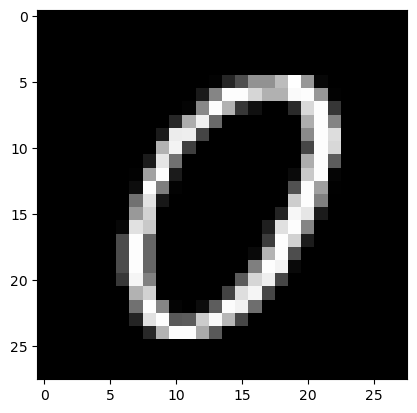

Prediction:  [0]
Label:  0


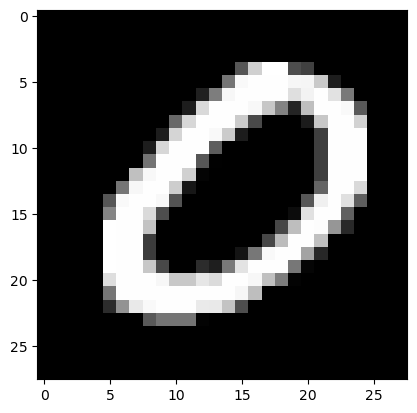

Prediction:  [1]
Label:  1


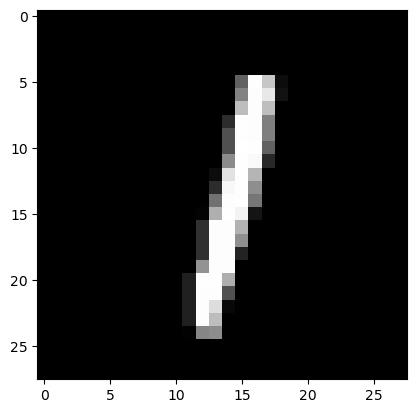

Prediction:  [3]
Label:  3


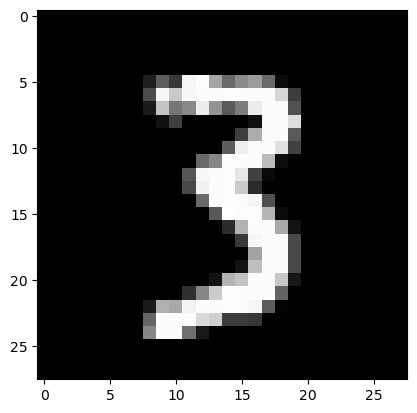

In [318]:
test_prediction(0, W1, b1, W2, b2,W3,b3)
test_prediction(1, W1, b1, W2, b2,W3,b3)
test_prediction(2, W1, b1, W2, b2,W3,b3)
test_prediction(3, W1, b1, W2, b2,W3,b3)

### Testing with actual dev data

In [319]:
dev_predictions = make_predictions(X_dev,W1,b1,W2,b2,W3,b3)
get_accuracy(dev_predictions,Y_dev)

0.8767857142857143

### 87.67%% ACCURACY !!!!
- Thus, our model generalized the data well and there is no overfitting issues